In [1]:
import cfe
import scanpy as sc

cfe.settings.backend = "python_function"
cfe.logger.setLevel("DEBUG")

[2025年02月21日 15时24分27秒] INFO                                                                                 
                                          _____     _ _ ______    _       ______            _                      
                                         / ____|   | | |  ____|  | |     |  ____|          | |                     
                                        | |     ___| | | |__ __ _| |_ ___| |__  __  ___ __ | | ___  _ __ ___ _ __  
                                        | |    / _ \ | |  __/ _` | __/ _ \  __| \ \/ / '_ \| |/ _ \| '__/ _ \ '__| 
                                        | |___|  __/ | | | | (_| | ||  __/ |____ >  <| |_) | | (_) | | |  __/ |    
                                         \_____\___|_|_|_|  \__,_|\__\___|______/_/\_\ .__/|_|\___/|_|  \___|_|    
                                                                                     | |                           
                                                                              

数据

In [2]:
# 读取scvelo的pancreas数据
adata = sc.read_h5ad("/home/huang/PyCode/scRNA/data/Pancreas/endocrinogenesis_day15.h5ad")
fadata = cfe.data.FateAnnData.from_anndata(adata)
fadata.layers["expression"] = fadata.layers["spliced"]
fadata.layers["count"] = fadata.layers["spliced"]

basis = "umap"
cluster_key = "clusters"

# sc.pp.subsample(fadata, n_obs=100) # 直接采样，细胞数量特别少时，某些聚类采集不到
# 手动保存每类的前两个细胞
obs = fadata.obs.copy()
obs.reset_index(inplace=True)
index = obs.groupby(cluster_key).apply(lambda x: x.head(2))["index"]
fadata = fadata[index]

fadata.obs.index = [f"cell_{i:03d}" for i in range(fadata.shape[0])]
fadata

                        DEBUG    Create a FateAnnData object from an existing AnnData object.                      
                        DEBUG    Create a FateAnnData object from an existing AnnData object.                      


/home/huang/.conda/envs/cfe/lib/python3.10/site-packages/anndata/compat/__init__.py:358: FutureWarning: Moving element from .uns['neighbors']['distances'] to .obsp['distances'].

This is where adjacency matrices should go now.
  warn(
/home/huang/.conda/envs/cfe/lib/python3.10/site-packages/anndata/compat/__init__.py:358: FutureWarning: Moving element from .uns['neighbors']['connectivities'] to .obsp['connectivities'].

This is where adjacency matrices should go now.
  warn(
/tmp/ipykernel_1904929/980782529.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  index = obs.groupby(cluster_key).apply(lambda x: x.head(2))["index"]
/tmp/ipykernel_1904929/980782529.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of 

AnnData object with n_obs × n_vars = 16 × 27998
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score'
    var: 'highly_variable_genes'
    uns: 'clusters_coarse_colors', 'clusters_colors', 'day_colors', 'neighbors', 'pca', 'cfe'
    obsm: 'X_pca', 'X_umap'
    layers: 'spliced', 'unspliced', 'expression', 'count'

In [3]:
import pandas as pd

# 手动添加参考里程碑
milestone_network = pd.DataFrame(
    data=[
        ["Ductal", "Ngn3 low EP"],
        ["Ngn3 low EP", "Ngn3 high EP"],
        ["Ngn3 high EP", "Pre-endocrine"],
        ["Pre-endocrine", "Alpha"],
        ["Pre-endocrine", "Beta"],
        ["Pre-endocrine", "Delta"],
        ["Pre-endocrine", "Epsilon"],
        ],
    columns=["from", "to"]
)

fadata.add_trajectory_mannually(milestone_network)

                        DEBUG    FateAnnData add_trajectory                                                        


/home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/data/fate_anndata.py:261: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  milestone_emb = np.array(list(obs.groupby(cluster_key).apply(lambda x: X_emb[list(x.index)].mean(axis=0))))


                        DEBUG    plot_trajectory                                                                   
                        DEBUG    add waypoints                                                                     
                        DEBUG    FateAnnData add_waypoints                                                         
[2025年02月21日 15时24分28秒] DEBUG    add waypoints shape is (211, 16), finished!                                 


AnnData object with n_obs × n_vars = 16 × 27998
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score', 'milestone_color', 'milestone'
    var: 'highly_variable_genes'
    uns: 'clusters_coarse_colors', 'clusters_colors', 'day_colors', 'neighbors', 'pca', 'cfe', 'milestone_colors', 'milestone_color_colors'
    obsm: 'X_pca', 'X_umap', 'milestone_network_emb'
    layers: 'spliced', 'unspliced', 'expression', 'count'

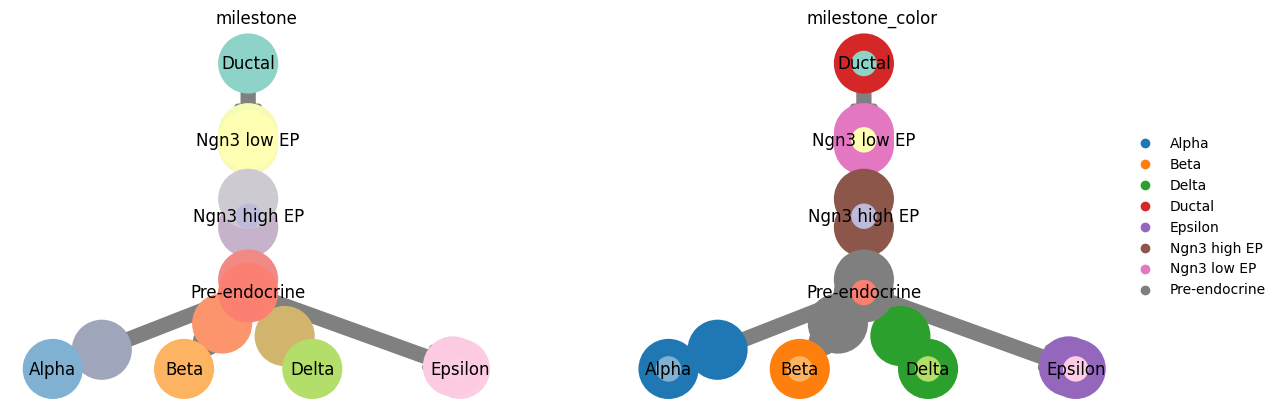

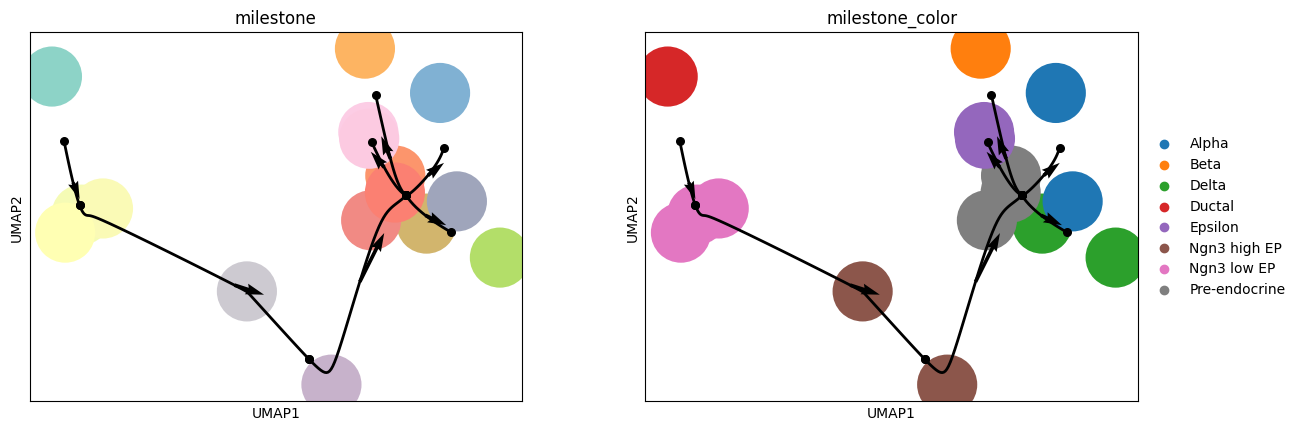

In [4]:
cluster_key = "milestone_color"
fadata.group_onto_nearest_milestones(cluster_key=cluster_key) # new cluster color

cluster_key_list = ["milestone", cluster_key]
cfe.plot.plot_graph(fadata, color=cluster_key_list)
cfe.plot.plot_trajectory(fadata, basis=basis, color=cluster_key_list)
fadata

[2025年02月21日 15时26分52秒] DEBUG    FunctionBackend __init__                                                    
                        INFO     Loaded function: <function cf_cluster_mst at 0x7a45101abd90> from                 
                                 /home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/method/function/cf_
                                 cluster_mst.py                                                                    
                        INFO     method_backend: <cfe.method.fate_function_backend.FunctionBackend object at       
                                 0x7a4512be3b50>                                                                   


                        DEBUG    FateAnnData add_trajectory                                                        
                        DEBUG    plot_trajectory                                                                   
                        DEBUG    add waypoints                                                                     
                        DEBUG    FateAnnData add_waypoints                                                         


/home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/method/function/cf_cluster_mst.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  centers = np.array(list(adata.obs.groupby(cluster_key).apply(lambda x: X_emb[list(x.index)].mean(axis=0))))


                        DEBUG    add waypoints shape is (209, 16), finished!                                       


<Axes: title={'center': 'milestone_color'}, xlabel='UMAP1', ylabel='UMAP2'>

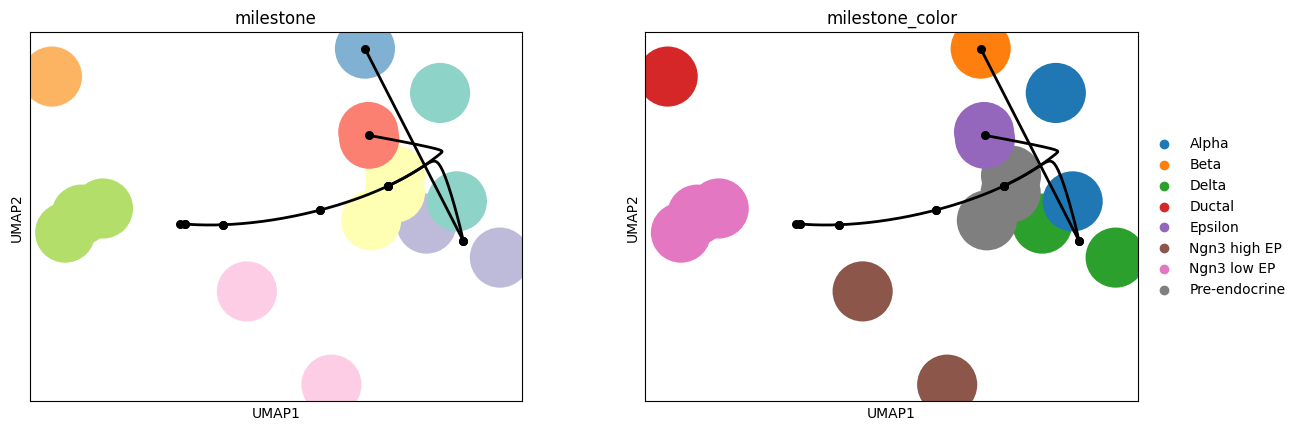

In [8]:
# cell_mst = cfe.method.FateMethod(method_name="cell_mst")
cluster_mst = cfe.method.FateMethod(method_name="cluster_mst")

prior_information = {
    "groups_id": fadata.obs[cluster_key].tolist()
}
fadata.add_prior_information(**prior_information)  # add prior information to fadata

cluster_mst.infer_trajectory(fadata)

cfe.plot.plot_trajectory(fadata, basis="umap", color=cluster_key_list)